<a href="https://colab.research.google.com/github/unknxwNS/Ihopeitworks/blob/main/%D0%9B%D0%912_%D0%9C%D0%9D_%D0%97%D0%B0%D0%B2%D0%B4%D0%B0%D0%BD%D0%BD%D1%8F_1_%D1%88%D0%B0%D0%B1%D0%BB%D0%BE%D0%BD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Лабораторна робота 2. Міхальов Андрій Володимирович, ФІТ 4-10


# Завдання 1

**Був присутній на парі**

Обробка та аналіз даних про ВВП країн. Датасет було отримано з Вікіпедії з використанням бібілотеки Pandas.

1. Вивести перші 5 рядків датасета

In [ ]:
import pandas as pd
import requests

url = "https://en.wikipedia.org/wiki/List_of_countries_by_GDP_(nominal)"
html = requests.get(url, headers={"User-Agent": "Mozilla/5.0"}).text

tables = pd.read_html(html)
df = tables[2]
df.head()

/tmp/ipykernel_2766/2141660363.py:7: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(html)


,Country/Territory,IMF (2026)[1],World Bank (2025)[6],United Nations (2024)[7]
0,World,126295331,118350166,111565144
1,United States,32383920,30769700,29298000
2,China[n 1],20851593,19498039,18743802
3,Germany,5452858,5050923,4659929
4,Japan,4379253,4435163,4026211


In [ ]:
df.columns

Index(['Country/Territory', 'IMF (2026)[1]', 'World Bank (2025)[6]',
       'United Nations (2024)[7]'],
      dtype='object')

2.	Визначити розмір датасета.

In [ ]:
df.info ()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 222 entries, 0 to 221
Data columns (total 4 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Country/Territory         222 non-null    object
 1   IMF (2026)[1]             222 non-null    object
 2   World Bank (2025)[6]      222 non-null    object
 3   United Nations (2024)[7]  222 non-null    object
dtypes: object(4)
memory usage: 7.1+ KB


 3.	Змінити назви стовпчиків на власний розсуд

In [ ]:
df.columns = (df.columns
    .str.replace(r'(\s*\[\d+\])+', '', regex=True)
    .str.replace('Country/Territory', 'Country', regex=False))

df

,Country,IMF (2026),World Bank (2025),United Nations (2024)
0,World,126295331,118350166,111565144
1,United States,32383920,30769700,29298000
2,China[n 1],20851593,19498039,18743802
3,Germany,5452858,5050923,4659929
4,Japan,4379253,4435163,4026211
...,...,...,...,...
217,Palau,377,345,310
218,Marshall Islands,342,308,281
219,Nauru,196,176,187
220,Montserrat,—N/a,—N/a,81


4.	Замініть у таблиці значення "—" на значення NaN. Перевірити наявність пропущених значень. При наявності, замінити пропущені значення на середнє значення.

In [ ]:
df.isnull().sum()

,0
Country,0
IMF (2026),0
World Bank (2025),0
United Nations (2024),0


In [ ]:
df['IMF (2026)'] = pd.to_numeric(df['IMF (2026)'], errors='coerce')
df['World Bank (2025)'] = pd.to_numeric(df['World Bank (2025)'], errors='coerce')
df['United Nations (2024)'] = pd.to_numeric(df['United Nations (2024)'], errors='coerce')

print(f'Types:\n{df.dtypes}')
df.head(10)

Types:
Country                   object
IMF (2026)               float64
World Bank (2025)        float64
United Nations (2024)    float64
dtype: object


,Country,IMF (2026),World Bank (2025),United Nations (2024)
0,World,126295331.0,118350166.0,111565144.0
1,United States,32383920.0,30769700.0,29298000.0
2,China[n 1],20851593.0,19498039.0,18743802.0
3,Germany,5452858.0,5050923.0,4659929.0
4,Japan,4379253.0,4435163.0,4026211.0
5,United Kingdom,4264794.0,4002588.0,3685881.0
6,India,4153191.0,3956067.0,3952244.0
7,France,3596094.0,3366316.0,3160443.0
8,Italy,2738164.0,2551557.0,2380825.0
9,Russia,2656452.0,2561310.0,2173386.0


In [ ]:
df.isnull().sum()

,0
Country,0
IMF (2026),30
World Bank (2025),35
United Nations (2024),9


In [ ]:
df.iloc[:, 1:] = df.iloc[:, 1:].apply(
    lambda x: x.fillna(x.mean()), axis=1
)

df.isnull().sum()

,0
Country,0
IMF (2026),8
World Bank (2025),8
United Nations (2024),8


In [ ]:
part = df.iloc[:, 1:]

row_filled = part.apply(lambda r: r.fillna(r.mean()), axis=1)
col_means = part.mean()

df.iloc[:, 1:] = row_filled.fillna(col_means)

df.isnull().sum()

,0
Country,0
IMF (2026),0
World Bank (2025),0
United Nations (2024),0


5. Ще раз вивести датасет

In [ ]:
df

,Country,IMF (2026),World Bank (2025),United Nations (2024)
0,World,126295331.0,118350166.0,111565144.0
1,United States,32383920.0,30769700.0,29298000.0
2,China[n 1],20851593.0,19498039.0,18743802.0
3,Germany,5452858.0,5050923.0,4659929.0
4,Japan,4379253.0,4435163.0,4026211.0
...,...,...,...,...
217,Palau,377.0,345.0,310.0
218,Marshall Islands,342.0,308.0,281.0
219,Nauru,196.0,176.0,187.0
220,Montserrat,81.0,81.0,81.0


6.	Перевірити наявність дублікатів. При наявності видалити дублікати.

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df = df[df["Country"] != "World"]
df

,Country,IMF (2026),World Bank (2025),United Nations (2024)
1,United States,32383920.0,30769700.0,29298000.0
2,China[n 1],20851593.0,19498039.0,18743802.0
3,Germany,5452858.0,5050923.0,4659929.0
4,Japan,4379253.0,4435163.0,4026211.0
5,United Kingdom,4264794.0,4002588.0,3685881.0
...,...,...,...,...
217,Palau,377.0,345.0,310.0
218,Marshall Islands,342.0,308.0,281.0
219,Nauru,196.0,176.0,187.0
220,Montserrat,81.0,81.0,81.0


7.	Вивести описову статистику датасету describe()

In [ ]:
df.describe()

,IMF (2026),World Bank (2025),United Nations (2024)
count,2.210000e+02,2.210000e+02,2.210000e+02
mean,6.158774e+05,5.760663e+05,5.434068e+05
std,2.675916e+06,2.530050e+06,2.412230e+06
min,6.500000e+01,5.700000e+01,5.600000e+01
25%,9.442000e+03,9.233000e+03,8.840000e+03
50%,4.884900e+04,4.809900e+04,4.276500e+04
75%,3.773650e+05,3.348550e+05,2.986970e+05
max,3.238392e+07,3.076970e+07,2.929800e+07


8. Визначте відхилення (різницю) між показниками IMF (2026) та World Bank (2025) для кожної країни. У яких країнах ці показники найбільше відрізняються (дати відповідь)?

In [ ]:
df['IMF_WB_Diff'] = abs(df['IMF (2026)'] - df['World Bank (2025)'])

max_diff = df['IMF_WB_Diff'].max()

country = df[df['IMF_WB_Diff'] == max_diff]['Country'].values[0]

print(f'{country} has the largest difference between IMF and WB: {max_diff}')

df.head(10)

United States has the largest difference between IMF and WB: 1614220.0


/tmp/ipykernel_2766/3912394511.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['IMF_WB_Diff'] = abs(df['IMF (2026)'] - df['World Bank (2025)'])


,Country,IMF (2026),World Bank (2025),United Nations (2024),IMF_WB_Diff
1,United States,32383920.0,30769700.0,29298000.0,1614220.0
2,China[n 1],20851593.0,19498039.0,18743802.0,1353554.0
3,Germany,5452858.0,5050923.0,4659929.0,401935.0
4,Japan,4379253.0,4435163.0,4026211.0,55910.0
5,United Kingdom,4264794.0,4002588.0,3685881.0,262206.0
6,India,4153191.0,3956067.0,3952244.0,197124.0
7,France,3596094.0,3366316.0,3160443.0,229778.0
8,Italy,2738164.0,2551557.0,2380825.0,186607.0
9,Russia,2656452.0,2561310.0,2173386.0,95142.0
10,Brazil,2635912.0,2279920.0,2185822.0,355992.0


9.	Обчисліть кореляцію між показниками IMF (2026), World Bank (2025) та United Nations (2024). Які пари змінних мають найвищу кореляцію?

In [ ]:
cor_IMF_WB = df['IMF (2026)'].corr(df['World Bank (2025)'])
cor_IMF_UN = df['IMF (2026)'].corr(df['United Nations (2024)'])
cor_WB_UN = df['World Bank (2025)'].corr(df['United Nations (2024)'])

print(f'Correlation between IMF and WB: {cor_IMF_WB}')
print(f'Correlation between IMF and UN: {cor_IMF_UN}')
print(f'Correlation between WB and UN: {cor_WB_UN}')

Correlation between IMF and WB: 0.9998779628509464
Correlation between IMF and UN: 0.999816606157696
Correlation between WB and UN: 0.9998604773125492


In [ ]:
max_cor = max(cor_IMF_WB, cor_IMF_UN, cor_WB_UN)

if max_cor == cor_IMF_WB:
    print('IMF and WB have the highest correlation')
elif max_cor == cor_IMF_UN:
    print('IMF and UN have the highest correlation')
else:
    print('WB and UN have the highest correlation')

IMF and WB have the highest correlation


Обчислити середнє значення за стовпцями

In [ ]:
mean_IMF = df['IMF (2026)'].mean()
mean_IMF

np.float64(615877.374740982)

In [ ]:
mean_WB = df['World Bank (2025)'].mean()
mean_WB

np.float64(576066.3084535036)

In [ ]:
mean_UN = df['United Nations (2024)'].mean()
mean_UN

np.float64(543406.7526959023)

11.	Обчисліть стандартне відхилення показників для кожної країни. Яка країна має найвищу варіативність у показниках між роками?

In [ ]:
df['std'] = df.iloc[:, 1:].std(axis=1)

# Find country with the highest standard deviation
max_std = df['std'].max()
country = df[df['std'] == max_std]['Country'].values[0]

print(f'{country} has the highest standard deviation: {max_std}')

df.head(10)

United States has the highest standard deviation: 14655779.964896671


/tmp/ipykernel_2766/497693565.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['std'] = df.iloc[:, 1:].std(axis=1)


,Country,IMF (2026),World Bank (2025),United Nations (2024),IMF_WB_Diff,std
1,United States,32383920.0,30769700.0,29298000.0,1614220.0,1.465578e+07
2,China[n 1],20851593.0,19498039.0,18743802.0,1353554.0,9.213488e+06
3,Germany,5452858.0,5050923.0,4659929.0,401935.0,2.348734e+06
4,Japan,4379253.0,4435163.0,4026211.0,55910.0,2.119895e+06
5,United Kingdom,4264794.0,4002588.0,3685881.0,262206.0,1.876098e+06
6,India,4153191.0,3956067.0,3952244.0,197124.0,1.913990e+06
7,France,3596094.0,3366316.0,3160443.0,229778.0,1.582291e+06
8,Italy,2738164.0,2551557.0,2380825.0,186607.0,1.194072e+06
9,Russia,2656452.0,2561310.0,2173386.0,95142.0,1.202576e+06
10,Brazil,2635912.0,2279920.0,2185822.0,355992.0,1.024125e+06


12.	Визначення країни з найвищим та найнижчим показниками: Знайдіть країну з найвищим та найнижчим показниками у кожному з років (IMF (2026), World Bank (2025), United Nations (2024)).

In [ ]:
max_IMF = df['IMF (2026)'].max()
min_IMF = df['IMF (2026)'].min()

max_WB = df['World Bank (2025)'].max()
min_WB = df['World Bank (2025)'].min()

max_UN = df['United Nations (2024)'].max()
min_UN = df['United Nations (2024)'].min()

print(f'Max IMF: {max_IMF}, Min IMF: {min_IMF}')
print(f'Max WB: {max_WB}, Min WB: {min_WB}')
print(f'Max UN: {max_UN}, Min UN: {min_UN}')

Max IMF: 32383920.0, Min IMF: 65.0
Max WB: 30769700.0, Min WB: 57.0
Max UN: 29298000.0, Min UN: 56.0


13.	Побудуйте гістограму для розподілу показників IMF (2025) серед всіх країн. Який вигляд має розподіл? Чи є країни, що виділяються?

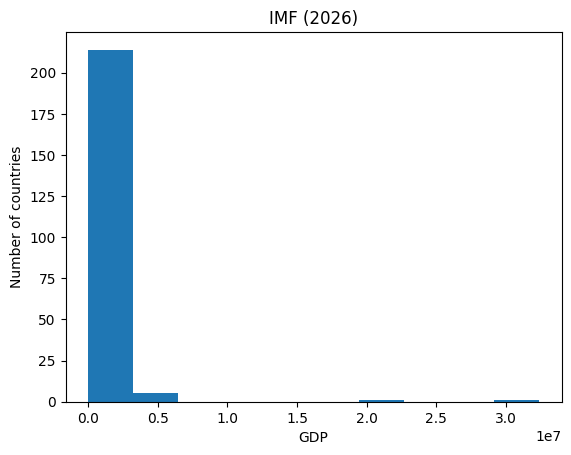

In [ ]:
import matplotlib.pyplot as plt

plt.hist(df['IMF (2026)'], bins=10)
plt.title('IMF (2026)')
plt.xlabel('GDP')
plt.ylabel('Number of countries')
plt.show()

14.	Розрахуйте частку кожної країни в загальному значенні для кожного року (IMF (2026), World Bank (2025), United Nations (2024)).
 Як змінюються частки країн з часом (дати відповідь)?

In [ ]:
df['IMF_Share'] = df['IMF (2026)'] / df['IMF (2026)'].sum()
df['WB_Share'] = df['World Bank (2025)'] / df['World Bank (2025)'].sum()
df['UN_Share'] = df['United Nations (2024)'] / df['United Nations (2024)'].sum()

df.head(10)

/tmp/ipykernel_2766/3347587809.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['IMF_Share'] = df['IMF (2026)'] / df['IMF (2026)'].sum()
/tmp/ipykernel_2766/3347587809.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['WB_Share'] = df['World Bank (2025)'] / df['World Bank (2025)'].sum()
/tmp/ipykernel_2766/3347587809.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the docu

,Country,IMF (2026),World Bank (2025),United Nations (2024),IMF_WB_Diff,std,IMF_Share,WB_Share,UN_Share
1,United States,32383920.0,30769700.0,29298000.0,1614220.0,1.465578e+07,0.237927,0.241690,0.243961
2,China[n 1],20851593.0,19498039.0,18743802.0,1353554.0,9.213488e+06,0.153198,0.153153,0.156078
3,Germany,5452858.0,5050923.0,4659929.0,401935.0,2.348734e+06,0.040062,0.039674,0.038803
4,Japan,4379253.0,4435163.0,4026211.0,55910.0,2.119895e+06,0.032175,0.034837,0.033526
5,United Kingdom,4264794.0,4002588.0,3685881.0,262206.0,1.876098e+06,0.031334,0.031440,0.030692
6,India,4153191.0,3956067.0,3952244.0,197124.0,1.913990e+06,0.030514,0.031074,0.032910
7,France,3596094.0,3366316.0,3160443.0,229778.0,1.582291e+06,0.026421,0.026442,0.026317
8,Italy,2738164.0,2551557.0,2380825.0,186607.0,1.194072e+06,0.020117,0.020042,0.019825
9,Russia,2656452.0,2561310.0,2173386.0,95142.0,1.202576e+06,0.019517,0.020119,0.018098
10,Brazil,2635912.0,2279920.0,2185822.0,355992.0,1.024125e+06,0.019366,0.017908,0.018201


15.	Візуалізуйте зміни в показниках для кожної країни за три роки на графіку. Які країни показують стабільне зростання або спад (дати відповідь)?

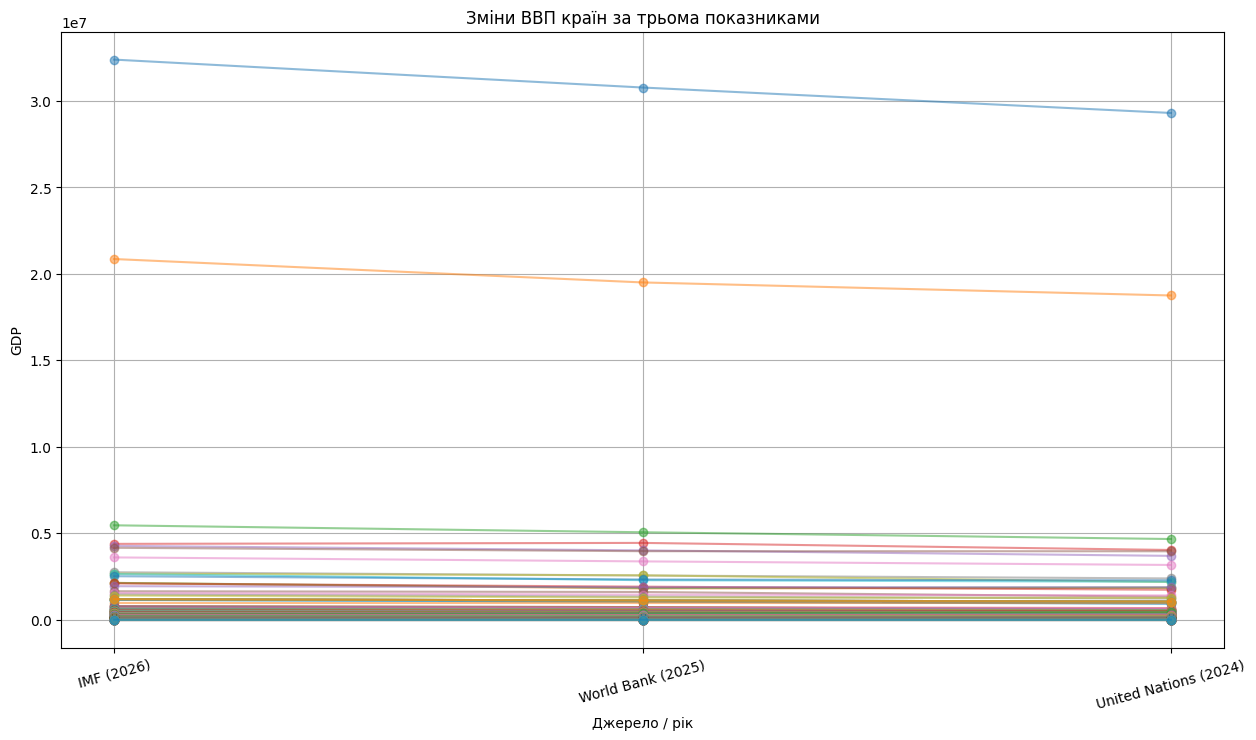

Країни зі стабільним зростанням:
['Iran', 'Ethiopia', 'Yemen']

Країни зі стабільним спадом:
['United States', 'China[n 1]', 'Germany', 'United Kingdom', 'India', 'France', 'Italy', 'Russia', 'Brazil', 'Canada', 'Spain', 'Turkey', 'Indonesia', 'Netherlands', 'Saudi Arabia', 'Switzerland', 'Poland', 'Ireland', 'Belgium', 'Sweden', 'Israel', 'Argentina', 'Singapore', 'Austria', 'United Arab Emirates', 'Norway', 'Thailand', 'Colombia', 'Vietnam', 'Malaysia', 'Philippines', 'Bangladesh', 'Denmark', 'Romania', 'South Africa', 'Pakistan', 'Hong Kong[n 4]', 'Czech Republic', 'Egypt', 'Chile', 'Peru', 'Portugal', 'Nigeria', 'Kazakhstan', 'Finland', 'Algeria', 'Greece', 'New Zealand', 'Hungary', 'Ukraine[n 5]', 'Morocco', 'Uzbekistan', 'Slovakia', 'Angola', 'Bulgaria', 'Kenya', 'Ecuador', 'Dominican Republic', 'Guatemala', 'DR Congo', 'Ghana', 'Oman', 'Croatia', 'Ivory Coast', 'Serbia', 'Luxembourg', 'Costa Rica', 'Lithuania', 'Belarus', 'Uruguay', 'Panama', 'Tanzania[n 6]', 'Slovenia', 'Myanma

In [ ]:
years = ['IMF (2026)', 'World Bank (2025)', 'United Nations (2024)']

plt.figure(figsize=(15, 8))

for _, row in df.iterrows():
    plt.plot(years, row[years], marker='o', alpha=0.5)

plt.title('Зміни ВВП країн за трьома показниками')
plt.xlabel('Джерело / рік')
plt.ylabel('GDP')
plt.xticks(rotation=15)
plt.grid(True)
plt.show()

increasing = []
decreasing = []

for _, row in df.iterrows():
    values = row[years].values

    if values[0] < values[1] < values[2]:
        increasing.append(row['Country'])
    elif values[0] > values[1] > values[2]:
        decreasing.append(row['Country'])

print("Країни зі стабільним зростанням:")
print(increasing)

print("\nКраїни зі стабільним спадом:")
print(decreasing)